In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('emails 2.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.6 MB


In [4]:
df.duplicated().sum()

np.int64(33)

In [5]:
df = df.drop_duplicates().reset_index(drop=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(5695, 2)

In [8]:
print(df['text'].iloc[0])

Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  mar

In [9]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [10]:
df['text_length'] = df['text'].str.len()


In [11]:
df['text_length'].describe()

count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: text_length, dtype: float64

In [12]:
df.sort_values('text_length').head(10)[['text','spam','text_length']]

,text,spam,text_length
1991,Subject: fyi,0,13
568,Subject: . jif .,1,18
2261,Subject: elena chilkina hi,0,27
2563,Subject: this hurricane elana,0,31
5381,Subject: proposal - kevin kindall,0,34
4381,Subject: re : rankings thank you .,0,35
3345,"Subject: itinerary phelim , fyi vince",0,40
2009,Subject: congratulations - well deserved .,0,43
3030,Subject: re : research allocation thank you,0,44
2836,Subject: your approval is requested thank you,0,46


In [13]:
print(df.sort_values('text_length',ascending=False)['text'].iloc[0][:1000])

Subject: from the enron india newsdesk - april 27 th newsclips  fyi news articles from indian press .  - - - - - - - - - - - - - - - - - - - - - - forwarded by sandeep kohli / enron _ development on 04 / 27 / 2001 08 : 24 am - - - - - - - - - - - - - - - - - - - - - - - - - - -  nikita varma  04 / 27 / 2001 07 : 51 am  to : nikita varma / enron _ development @ enron _ development  cc : ( bcc : sandeep kohli / enron _ development )  subject : from the enron india newsdesk - april 27 th newsclips  friday apr 27 2001 , http : / / www . economictimes . com / today / cmo 3 . htm  dpc board empowers md to cancel mseb contract  friday apr 27 2001 , http : / / www . economictimes . com / today / 27 compl 1 . htm  mseb pays rs 134 cr under ' protest ' to dpc  friday , april 27 , 001 , http : / / www . businessstandard . com / today / economy 4 . asp ? menu = 3  enron india md authorised to terminate ppa  friday , april 27 , 2001 , http : / / www . financialexpress . com / fe 20010427 / topl . h

In [14]:
df.shape

(5695, 3)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5695 entries, 0 to 5694
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         5695 non-null   str  
 1   spam         5695 non-null   int64
 2   text_length  5695 non-null   int64
dtypes: int64(2), str(1)
memory usage: 8.6 MB


In [16]:
df = df.drop(columns='text_length')

In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: naturally irresistible your corporate...,subject naturally irresistible your corporate ...
1,Subject: the stock trading gunslinger fanny i...,subject the stock trading gunslinger fanny is ...
2,Subject: unbelievable new homes made easy im ...,subject unbelievable new homes made easy im wa...
3,Subject: 4 color printing special request add...,subject color printing special request additio...
4,"Subject: do not have money , get software cds ...",subject do not have money get software cds fro...


In [19]:
print(df['clean_text'].iloc[0])

subject naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish statlonery and outstanding website will make the task much easier we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader it isguite ciear that without good products effective business organization and practicable aim it will be hotat nowadays market but we do promise that your marketing efforts will become much more effective here is the list of clear benefits creativeness hand made original logos specially done to reflect your distinctive company image convenience logo and stationery are provided in all formats easy to use content management system letsyou change your website content and even its structure promptness you will see logo drafts within three business days affordability your marketing break through shouldn t make gaps in your budget sati

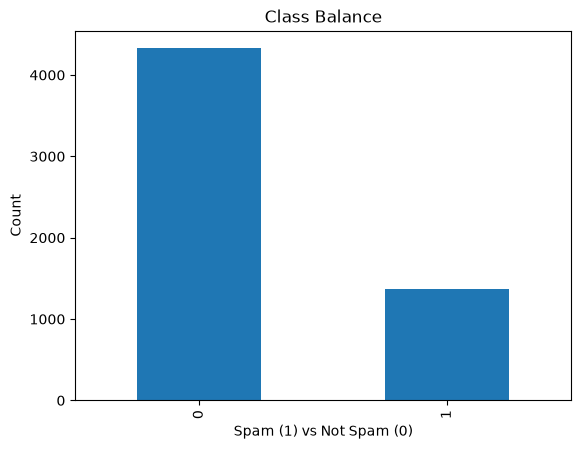

In [20]:
df['spam'].value_counts().plot(kind='bar')
plt.xlabel('Spam (1) vs Not Spam (0)')
plt.ylabel('Count')
plt.title('Class Balance')
plt.show()

In [21]:
baseline_acc = df['spam'].value_counts(normalize=True).max()
print(f"Lazy baseline accuracy: {baseline_acc:.4f}")

Lazy baseline accuracy: 0.7598


In [22]:
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_counts = Counter(all_words)
word_counts.most_common(20)

[('the', 49910),
 ('to', 41534),
 ('and', 27322),
 ('of', 23656),
 ('a', 19853),
 ('you', 19027),
 ('in', 17901),
 ('i', 17287),
 ('for', 16638),
 ('enron', 13329),
 ('on', 12645),
 ('is', 12544),
 ('ect', 11411),
 ('subject', 10119),
 ('this', 9993),
 ('that', 9247),
 ('your', 9243),
 ('be', 9202),
 ('with', 8810),
 ('we', 8637)]

In [23]:
spam_words = ' '.join(df[df['spam']==1]['clean_text']).split()
ham_words = ' '.join(df[df['spam']==0]['clean_text']).split()

spam_counts = Counter(spam_words)
ham_counts = Counter(ham_words)

print("Top spam words:", spam_counts.most_common(15))
print()
print("Top ham words:", ham_counts.most_common(15))

Top spam words: [('the', 8975), ('to', 8165), ('and', 6517), ('of', 5629), ('you', 4920), ('a', 4700), ('in', 3886), ('your', 3730), ('for', 3186), ('is', 2977), ('this', 2822), ('that', 1896), ('i', 1777), ('with', 1734), ('we', 1724)]

Top ham words: [('the', 40935), ('to', 33369), ('and', 20805), ('of', 18027), ('i', 15510), ('a', 15153), ('you', 14107), ('in', 14015), ('for', 13452), ('enron', 13329), ('ect', 11410), ('on', 11062), ('is', 9567), ('subject', 8545), ('vince', 8468)]


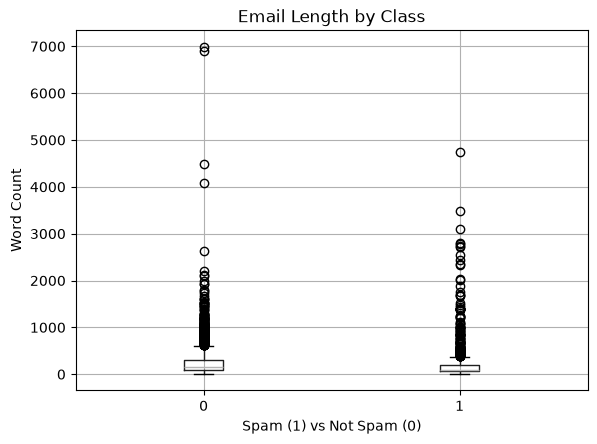

In [24]:
df['word_count'] = df['clean_text'].str.split().str.len()
df.boxplot(column='word_count', by='spam')
plt.xlabel('Spam (1) vs Not Spam (0)')
plt.ylabel('Word Count')
plt.title('Email Length by Class')
plt.suptitle('')
plt.show()

In [25]:
stopwords = {'the','to','and','of','a','you','in','i','for','on','is','this',
             'that','your','be','with','we','it','are','have','was','as',
             'at','from','or','will','not','can','has','if','but','by',
             'an','all','so','do','my','me','our','us','they','their'}

spam_filtered = {w: c for w, c in spam_counts.most_common(40) if w not in stopwords}
ham_filtered = {w: c for w, c in ham_counts.most_common(40) if w not in stopwords}

print("Top spam words (no stopwords):", list(spam_filtered.items())[:15])
print()
print("Top ham words (no stopwords):", list(ham_filtered.items())[:15])

Top spam words (no stopwords): [('subject', 1574), ('s', 1342), ('com', 999), ('business', 844), ('company', 805), ('email', 804), ('here', 770)]

Top ham words (no stopwords): [('enron', 13329), ('ect', 11410), ('subject', 8545), ('vince', 8468), ('hou', 5567), ('s', 5146), ('am', 4785), ('kaminski', 4723), ('com', 4397), ('please', 4332), ('would', 4124), ('cc', 3862), ('re', 3794)]


In [26]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

spam_filtered = {w: c for w, c in spam_counts.most_common(60) if w not in ENGLISH_STOP_WORDS and len(w) > 1}
ham_filtered = {w: c for w, c in ham_counts.most_common(60) if w not in ENGLISH_STOP_WORDS and len(w) > 1}

print("Top spam words (no stopwords):", list(spam_filtered.items())[:15])
print()
print("Top ham words (no stopwords):", list(ham_filtered.items())[:15])

Top spam words (no stopwords): [('subject', 1574), ('com', 999), ('business', 844), ('company', 805), ('email', 804), ('information', 740), ('money', 662), ('free', 606), ('http', 600), ('mail', 586), ('click', 531), ('just', 524)]

Top ham words (no stopwords): [('enron', 13329), ('ect', 11410), ('subject', 8545), ('vince', 8468), ('hou', 5567), ('kaminski', 4723), ('com', 4397), ('cc', 3862), ('pm', 3247), ('research', 2635), ('thanks', 2509), ('know', 2281), ('group', 2235), ('time', 2197), ('energy', 2103)]


In [27]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True))
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True))

Train shape: (4556,) (4556,)
Test shape: (1139,) (1139,)

Train class balance:
spam
0    0.759877
1    0.240123
Name: proportion, dtype: float64

Test class balance:
spam
0    0.759438
1    0.240562
Name: proportion, dtype: float64


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

In [30]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [31]:
print("Train vector shape:", X_train_vec.shape)
print("Test vector shape:", X_test_vec.shape)

Train vector shape: (4556, 5000)
Test vector shape: (1139, 5000)


In [32]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_vec, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
y_pred_log_reg = log_reg.predict(X_test_vec)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Precision:", precision_score(y_test, y_pred_log_reg))
print("Recall:", recall_score(y_test, y_pred_log_reg))
print("F1 Score:", f1_score(y_test, y_pred_log_reg))

Accuracy: 0.9833187006145742
Precision: 0.9885057471264368
Recall: 0.9416058394160584
F1 Score: 0.9644859813084112


In [36]:
cm = confusion_matrix(y_test, y_pred_log_reg)
print(cm)

[[862   3]
 [ 16 258]]


In [37]:
print(classification_report(y_test, y_pred_log_reg))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       865
           1       0.99      0.94      0.96       274

    accuracy                           0.98      1139
   macro avg       0.99      0.97      0.98      1139
weighted avg       0.98      0.98      0.98      1139



In [38]:
feature_names = vectorizer.get_feature_names_out()
coefficients = log_reg.coef_[0]

top_spam_idx = coefficients.argsort()[-15:][::-1]
top_ham_idx = coefficients.argsort()[:15]

print("Top words pushing toward SPAM:")
for i in top_spam_idx:
    print(feature_names[i], round(coefficients[i], 2))

print()
print("Top words pushing toward NOT SPAM:")
for i in top_ham_idx:
    print(feature_names[i], round(coefficients[i], 2))

Top words pushing toward SPAM:
click 3.39
money 2.84
software 2.78
life 2.55
http 2.48
account 2.39
online 2.35
save 2.33
viagra 2.24
free 2.19
adobe 2.02
man 1.93
sex 1.87
company 1.79
website 1.75

Top words pushing toward NOT SPAM:
enron -5.74
vince -5.51
ect -3.14
thanks -2.72
research -2.63
kaminski -2.52
model -2.3
energy -2.19
attached -1.92
meeting -1.92
risk -1.87
conference -1.82
houston -1.77
pm -1.74
edu -1.69


In [39]:
leak_words = ['enron', 'vince', 'ect', 'kaminski']

vectorizer_ablation = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_ablation = vectorizer_ablation.fit_transform(X_train)
X_test_ablation = vectorizer_ablation.transform(X_test)

leak_indices = [vectorizer_ablation.vocabulary_[w] for w in leak_words if w in vectorizer_ablation.vocabulary_]

import numpy as np
mask = np.ones(X_train_ablation.shape[1], dtype=bool)
mask[leak_indices] = False

X_train_ablation = X_train_ablation[:, mask]
X_test_ablation = X_test_ablation[:, mask]

log_reg_ablation = LogisticRegression(max_iter=1000)
log_reg_ablation.fit(X_train_ablation, y_train)
y_pred_ablation = log_reg_ablation.predict(X_test_ablation)

print("Accuracy without leak words:", accuracy_score(y_test, y_pred_ablation))
print("Precision:", precision_score(y_test, y_pred_ablation))
print("Recall:", recall_score(y_test, y_pred_ablation))
print("F1:", f1_score(y_test, y_pred_ablation))

Accuracy without leak words: 0.9780509218612818
Precision: 0.9882352941176471
Recall: 0.9197080291970803
F1: 0.9527410207939508


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_vec, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [41]:
y_pred_rf = rf.predict(X_test_vec)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9877085162423178
Precision: 0.9814814814814815
Recall: 0.9671532846715328
F1 Score: 0.9742647058823529


In [43]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[860   5]
 [  9 265]]


In [44]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       865
           1       0.98      0.97      0.97       274

    accuracy                           0.99      1139
   macro avg       0.99      0.98      0.98      1139
weighted avg       0.99      0.99      0.99      1139



In [45]:
importances = rf.feature_importances_
top_idx = importances.argsort()[-20:][::-1]

print("Top 20 most important features (Random Forest):")
for i in top_idx:
    print(feature_names[i], round(importances[i], 4))

Top 20 most important features (Random Forest):
vince 0.0554
enron 0.0455
life 0.0171
click 0.016
money 0.0146
pm 0.0144
cc 0.0141
kaminski 0.0134
save 0.0122
thanks 0.0122
online 0.011
http 0.011
viagra 0.0107
hou 0.0105
ect 0.0102
software 0.0093
research 0.0093
houston 0.0092
low 0.0089
attached 0.0078


In [46]:
rf_ablation = RandomForestClassifier(random_state=42)
rf_ablation.fit(X_train_ablation, y_train)
y_pred_rf_ablation = rf_ablation.predict(X_test_ablation)

print("Accuracy without leak words:", accuracy_score(y_test, y_pred_rf_ablation))
print("Precision:", precision_score(y_test, y_pred_rf_ablation))
print("Recall:", recall_score(y_test, y_pred_rf_ablation))
print("F1:", f1_score(y_test, y_pred_rf_ablation))

Accuracy without leak words: 0.9824407374890255
Precision: 0.9810606060606061
Recall: 0.9452554744525548
F1: 0.9628252788104089


In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20, 40],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_vec, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [48]:
print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 score: 0.9647319073636125


In [49]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_vec)

print("Tuned Random Forest — Test Set Results")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf))

Tuned Random Forest — Test Set Results
Accuracy: 0.9877085162423178
Precision: 0.9814814814814815
Recall: 0.9671532846715328
F1 Score: 0.9742647058823529


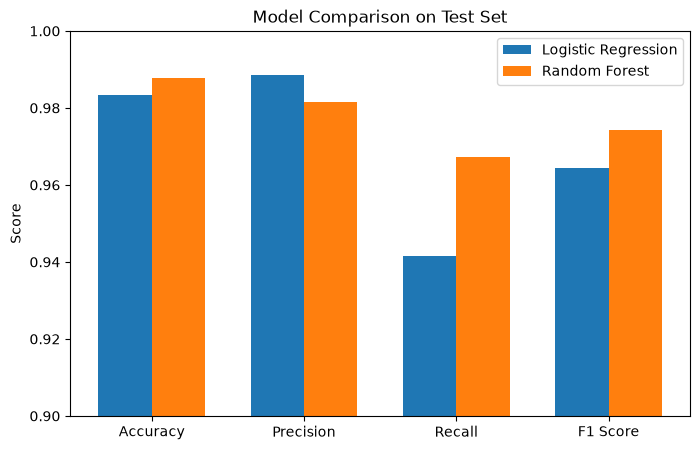

In [50]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
log_reg_scores = [
    accuracy_score(y_test, y_pred_log_reg),
    precision_score(y_test, y_pred_log_reg),
    recall_score(y_test, y_pred_log_reg),
    f1_score(y_test, y_pred_log_reg)
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, log_reg_scores, width, label='Logistic Regression')
ax.bar(x + width/2, rf_scores, width, label='Random Forest')

ax.set_ylabel('Score')
ax.set_title('Model Comparison on Test Set')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.9, 1.0)
ax.legend()
plt.show()

In [51]:
import joblib

joblib.dump(best_rf, 'spam_classifier_rf.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [52]:
loaded_model = joblib.load('spam_classifier_rf.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

sample_email = ["click here to win free money now viagra"]
sample_clean = [clean_text(sample_email[0])]
sample_vec = loaded_vectorizer.transform(sample_clean)

prediction = loaded_model.predict(sample_vec)
print("Prediction:", "Spam" if prediction[0] == 1 else "Not Spam")

Prediction: Spam
